### Import Library

In [69]:
# Import library 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings

### Set option in pandas to display all rows and columns in dataset

In [70]:
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows", None)

### Ignore library Deprecated warning messages

In [71]:
# def ignore_warning(): # define function 
#     return warnings.filterwarnings(action='ignore', category= DeprecationWarning, module=r'.*randpool')

# ignore_warning() # function call
warnings.filterwarnings('ignore')


### Load Dataset

In [72]:
def load_dataset(dataset_url): # define function
    return  pd.read_csv(dataset_url) # to read csv data
 
# call function load_dataset() and store dataset value in population_dataframe
population_dataframe = load_dataset('PEA04.20231018T191000.csv')

# EDA (Exploratory Data Analysis)

In [73]:
# Dimensions of dataset
population_dataframe.shape

(6669, 7)

In [74]:
# Gives top 5 rows of dataset
population_dataframe.tail(10)

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
6659,Estimated Population (Persons in April),2023,All ages,Male,Midland,Thousand,161.3
6660,Estimated Population (Persons in April),2023,All ages,Female,State,Thousand,2675.4
6661,Estimated Population (Persons in April),2023,All ages,Female,Border,Thousand,217.2
6662,Estimated Population (Persons in April),2023,All ages,Female,West,Thousand,252.9
6663,Estimated Population (Persons in April),2023,All ages,Female,Mid-West,Thousand,263.9
6664,Estimated Population (Persons in April),2023,All ages,Female,South-East,Thousand,237.5
6665,Estimated Population (Persons in April),2023,All ages,Female,South-West,Thousand,383.8
6666,Estimated Population (Persons in April),2023,All ages,Female,Dublin,Thousand,765.6
6667,Estimated Population (Persons in April),2023,All ages,Female,Mid-East,Thousand,391.3
6668,Estimated Population (Persons in April),2023,All ages,Female,Midland,Thousand,163.2


In [75]:
# Gives bottom 5 rows of dataset
population_dataframe.tail()

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
6664,Estimated Population (Persons in April),2023,All ages,Female,South-East,Thousand,237.5
6665,Estimated Population (Persons in April),2023,All ages,Female,South-West,Thousand,383.8
6666,Estimated Population (Persons in April),2023,All ages,Female,Dublin,Thousand,765.6
6667,Estimated Population (Persons in April),2023,All ages,Female,Mid-East,Thousand,391.3
6668,Estimated Population (Persons in April),2023,All ages,Female,Midland,Thousand,163.2


In [76]:
# Gives random sample data
population_dataframe.sample(10)

,STATISTIC Label,Year,Age Group,Sex,Region,UNIT,VALUE
4750,Estimated Population (Persons in April),2020,20 - 24 years,Female,Mid-East,Thousand,20.4
1889,Estimated Population (Persons in April),2014,60 - 64 years,Female,Midland,Thousand,6.7
2170,Estimated Population (Persons in April),2015,20 - 24 years,Male,Border,Thousand,10.3
429,Estimated Population (Persons in April),2011,75 - 79 years,Female,Dublin,Thousand,15.6
1186,Estimated Population (Persons in April),2013,25 - 29 years,Female,Mid-East,Thousand,20.9
6062,Estimated Population (Persons in April),2022,75 - 79 years,Male,South-West,Thousand,11.5
6326,Estimated Population (Persons in April),2023,30 - 34 years,Both sexes,Midland,Thousand,18.7
3926,Estimated Population (Persons in April),2018,60 - 64 years,Male,West,Thousand,13.0
3762,Estimated Population (Persons in April),2018,30 - 34 years,Male,State,Thousand,162.2
1598,Estimated Population (Persons in April),2014,10 - 14 years,Both sexes,South-West,Thousand,44.3


In [77]:
# rename columns name i.e no space should be in columns name
# use of try and except to handle if value list has not appropriate length for column
new_column_name = ['statistic_label','year','age_group','sex','region','unit','value']

def columns_dict(cols):
    new_col = {}
    
    if len(cols) == len(population_dataframe.columns):
        try:
            for i in range(len(cols)):
                new_col[population_dataframe.columns[i]] = cols[i]
        except:
            print("An error occurred while creating the column dictionary.")
    else:
        print(f"Your length of Population Dataframe {len(population_dataframe.columns)} != {len(new_column_name)} with length of New Column ")
    
    return new_col

col_dict = columns_dict(new_column_name)


### Rename Column names

In [78]:

# inplace = True set the values permenantly so that we can use new columns name
population_dataframe.rename(columns=col_dict, inplace=True)

In [79]:
# drop column STATISTIC Label and Unit because it
population_dataframe.drop({'statistic_label', 'unit'}, axis=1, inplace=True)
population_dataframe.head()

,year,age_group,sex,region,value
0,2011,0 - 4 years,Both sexes,State,356.0
1,2011,0 - 4 years,Both sexes,Border,30.7
2,2011,0 - 4 years,Both sexes,West,32.6
3,2011,0 - 4 years,Both sexes,Mid-West,35.0
4,2011,0 - 4 years,Both sexes,South-East,32.0


In [80]:
# Checking the types of data
population_dataframe.dtypes

year           int64
age_group     object
sex           object
region        object
value        float64
dtype: object

In [81]:
# isna().sum() provide sum of null value in each column in datasets
population_dataframe.isnull().sum()

year         0
age_group    0
sex          0
region       0
value        0
dtype: int64

In [82]:
# info() provide information about datasets
population_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6669 entries, 0 to 6668
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   year       6669 non-null   int64  
 1   age_group  6669 non-null   object 
 2   sex        6669 non-null   object 
 3   region     6669 non-null   object 
 4   value      6669 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 260.6+ KB


In [83]:
population_dataframe.count()

year         6669
age_group    6669
sex          6669
region       6669
value        6669
dtype: int64

In [84]:
# count duplicated value in dataset
population_dataframe.duplicated().sum()

0

In [85]:
# describe() generate statistical descriptive value of dataset
population_dataframe.describe()

,year,value
count,6669.000000,6669.000000
mean,2017.000000,75.670460
std,3.741938,281.512172
min,2011.000000,1.200000
25%,2014.000000,12.500000
50%,2017.000000,20.700000
75%,2020.000000,42.200000
max,2023.000000,5281.600000


In [86]:
# describe(include=object) generate statistical descriptive value for object datatype of dataset
population_dataframe.describe(include=object)

,age_group,sex,region
count,6669,6669,6669
unique,19,3,9
top,0 - 4 years,Both sexes,State
freq,351,2223,741


In [87]:
# It return all unique value of series object
population_dataframe['age_group'].unique()

array(['0 - 4 years', '5 - 9 years', '10 - 14 years', '15 - 19 years',
       '20 - 24 years', '25 - 29 years', '30 - 34 years', '35 - 39 years',
       '40 - 44 years', '45 - 49 years', '50 - 54 years', '55 - 59 years',
       '60 - 64 years', '65 - 69 years', '70 - 74 years', '75 - 79 years',
       '80 - 84 years', '85 years and over', 'All ages'], dtype=object)

In [88]:
# It return all unique value of series object
population_dataframe['year'].unique()

array([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023])

#### Remove State from observation

In [89]:
# Remove State observation from region because state is sum of all other 8 region population

new_population_dataframe = population_dataframe.loc[population_dataframe['region'] != 'State']
new_population_dataframe.head()

,year,age_group,sex,region,value
1,2011,0 - 4 years,Both sexes,Border,30.7
2,2011,0 - 4 years,Both sexes,West,32.6
3,2011,0 - 4 years,Both sexes,Mid-West,35.0
4,2011,0 - 4 years,Both sexes,South-East,32.0
5,2011,0 - 4 years,Both sexes,South-West,50.1


In [90]:
# Unique region 
new_population_dataframe['region'].unique()

array(['Border', 'West', 'Mid-West', 'South-East', 'South-West', 'Dublin',
       'Mid-East', 'Midland'], dtype=object)

In [91]:
# Unique sex 
new_population_dataframe['sex'].unique()

array(['Both sexes', 'Male', 'Female'], dtype=object)

In [92]:
# Unique age_group
new_population_dataframe['age_group'].unique()

array(['0 - 4 years', '5 - 9 years', '10 - 14 years', '15 - 19 years',
       '20 - 24 years', '25 - 29 years', '30 - 34 years', '35 - 39 years',
       '40 - 44 years', '45 - 49 years', '50 - 54 years', '55 - 59 years',
       '60 - 64 years', '65 - 69 years', '70 - 74 years', '75 - 79 years',
       '80 - 84 years', '85 years and over', 'All ages'], dtype=object)

#### Remove Both sexes and All age group from observation

In [93]:
# Remove Both sexes observation from sex column and All ages observation from age_group column because both sexes is sum of male and female population and all ages are sum of rest of categorical age

new_population_dataframe = new_population_dataframe.loc[(new_population_dataframe['sex'] != 'Both sexes') & (new_population_dataframe['age_group'] != 'All ages')]
new_population_dataframe.reset_index(drop=True, inplace=True)
new_population_dataframe.tail(5)

,year,age_group,sex,region,value
3739,2023,85 years and over,Female,South-East,5.0
3740,2023,85 years and over,Female,South-West,8.1
3741,2023,85 years and over,Female,Dublin,15.5
3742,2023,85 years and over,Female,Mid-East,6.0
3743,2023,85 years and over,Female,Midland,3.0


In [94]:
# Boxplot helps to identify outliers
def plot_boxplot(col_name):
    plt.figure(figsize=(8,6))
    sns.boxplot(x=col_name);

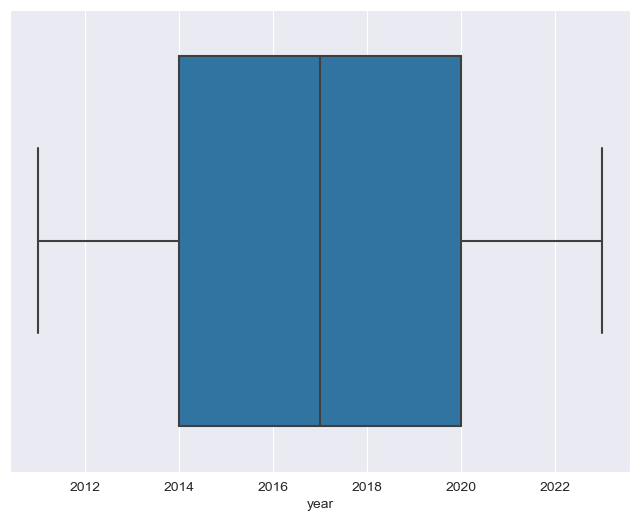

In [95]:
# call plot_boxplot for year column, Hence there are no outliers
plot_boxplot(new_population_dataframe['year'])

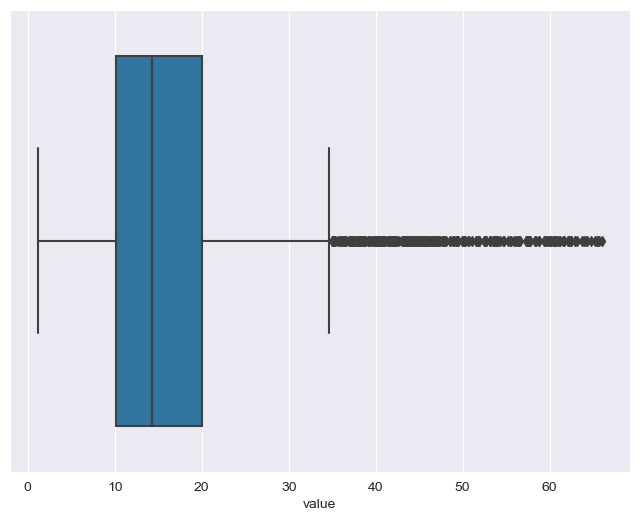

In [96]:
# call plot_boxplot function for value column, Hence there are outliers
plot_boxplot(new_population_dataframe['value'])

IQR 9.8
lower_limit -4.500000000000002
upper_limit 34.7


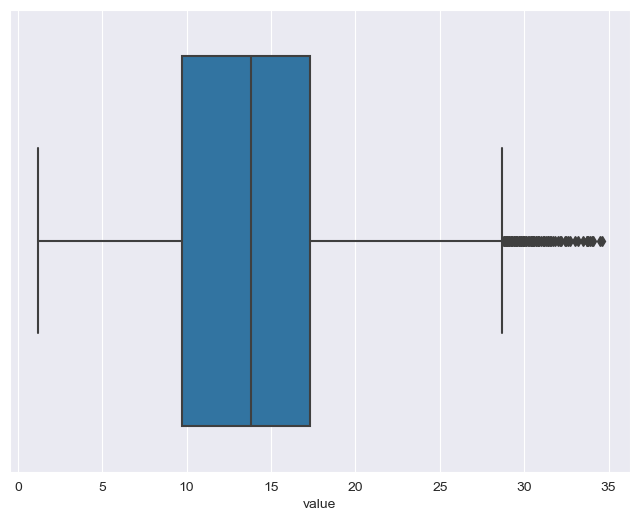

In [97]:
# Function to remove outliers from datasets by using IQR (Interquartile Range)

def remove_outliers(col_name):
    Q1 = new_population_dataframe[col_name].quantile(0.25)
    Q3 = new_population_dataframe[col_name].quantile(0.75)
    IQR = Q3-Q1 
    lower_limit = Q1 - 1.5*IQR
    upper_limit = Q3 + 1.5*IQR
    print('IQR',IQR)
    print('lower_limit',lower_limit)
    print('upper_limit',upper_limit)
    new_data = new_population_dataframe[(new_population_dataframe['value'] > lower_limit) & (new_population_dataframe['value'] < upper_limit)]
    return new_data
    
newdata_no_outliers = remove_outliers('value')

plot_boxplot(newdata_no_outliers['value'])


,year,value
year,1.000,0.078
value,0.078,1.000


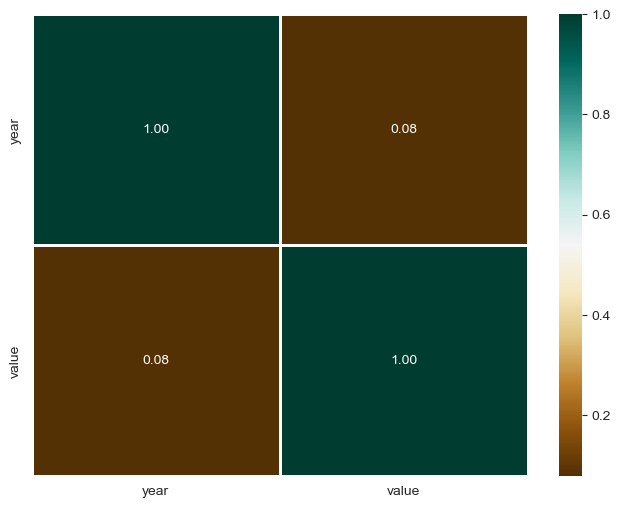

In [98]:
plt.figure(figsize=(8,6))
# correlation = population_dataframe.corr()
correlation = newdata_no_outliers.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, fmt='.2f', linewidths=2, cmap="BrBG")
correlation


In [99]:
newdata_no_outliers.describe()

,year,value
count,3441.000000,3441.000000
mean,2016.977332,14.151148
std,3.742366,6.793485
min,2011.000000,1.200000
25%,2014.000000,9.700000
50%,2017.000000,13.800000
75%,2020.000000,17.300000
max,2023.000000,34.600000


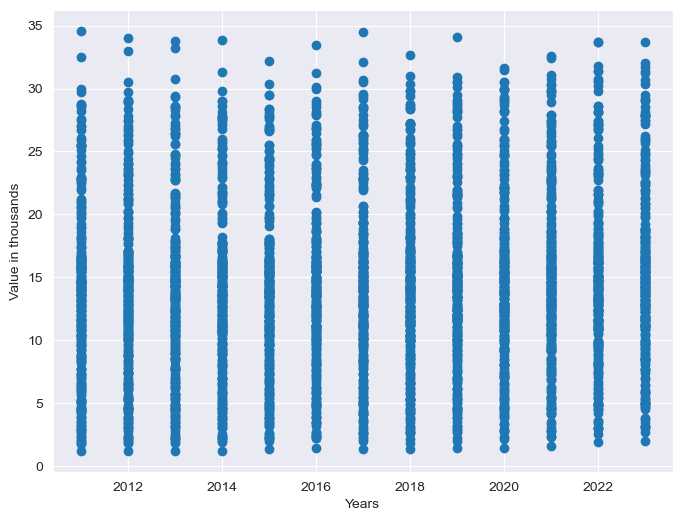

In [100]:
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(newdata_no_outliers["year"], newdata_no_outliers["value"])
# ax.scatter(population_dataframe["year"], population_dataframe["value"])

ax.set_xlabel("Years")
ax.set_ylabel("Value in thousands")
plt.show()

In [101]:
newdata_no_outliers.describe()

,year,value
count,3441.000000,3441.000000
mean,2016.977332,14.151148
std,3.742366,6.793485
min,2011.000000,1.200000
25%,2014.000000,9.700000
50%,2017.000000,13.800000
75%,2020.000000,17.300000
max,2023.000000,34.600000


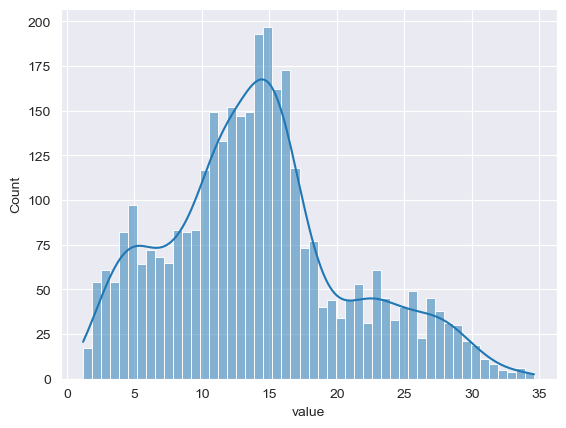

In [102]:
# Histplot explain distribution of data i.e Symmetric distribution  data
sns.histplot(data=newdata_no_outliers, x='value', kde=True, bins=50);

#### Calculate Skewness for distribution of data

In [103]:
# best skew value should be -3 to +3
skew_value = stats.skew(newdata_no_outliers['value'], axis=0, bias=True)
print('Skew Value',skew_value)

Skew Value 0.4695898846117097


#### Calculate kurtosis for distribution of data

In [104]:
# best kurtosis value should be -10 to +10
kurtosis_value = stats.kurtosis(newdata_no_outliers['value'], axis=0, bias=True)
print('kurtosis Value',kurtosis_value)

kurtosis Value -0.11496544853305002


In [105]:
newdata_no_outliers.describe(include=object)

,age_group,sex,region
count,3441,3441,3441
unique,18,2,8
top,85 years and over,Male,Border
freq,208,1723,468


In [106]:
newdata_no_outliers['age_group'].unique()

array(['0 - 4 years', '5 - 9 years', '10 - 14 years', '15 - 19 years',
       '20 - 24 years', '25 - 29 years', '30 - 34 years', '35 - 39 years',
       '40 - 44 years', '45 - 49 years', '50 - 54 years', '55 - 59 years',
       '60 - 64 years', '65 - 69 years', '70 - 74 years', '75 - 79 years',
       '80 - 84 years', '85 years and over'], dtype=object)

# Statistical Data Analysis and visualization

### Total population by year of all states from 2011-2023

In [107]:

all_age_bt_sex_state_df = population_dataframe.loc[(population_dataframe['sex'] == 'Both sexes') & (population_dataframe['region'] == 'State') & (population_dataframe['age_group'] == 'All ages')].reset_index(drop=True)


In [108]:
# Statistical value for bar graph year and population
all_age_bt_sex_state_df[['year','value']]

,year,value
0,2011,4574.9
1,2012,4593.7
2,2013,4614.7
3,2014,4645.4
4,2015,4687.8
5,2016,4739.6
6,2017,4810.9
7,2018,4884.9
8,2019,4958.5
9,2020,5029.9


#### Statistical value  for bar graph

In [109]:
print(f"Max: {all_age_bt_sex_state_df[['year','value']].max()},  Min: {all_age_bt_sex_state_df[['year','value']].min()}, Mean: {all_age_bt_sex_state_df[['year','value']].mean()} ")


Max: year     2023.0
value    5281.6
dtype: float64,  Min: year     2011.0
value    4574.9
dtype: float64, Mean: year     2017.000000
value    4852.353846
dtype: float64 


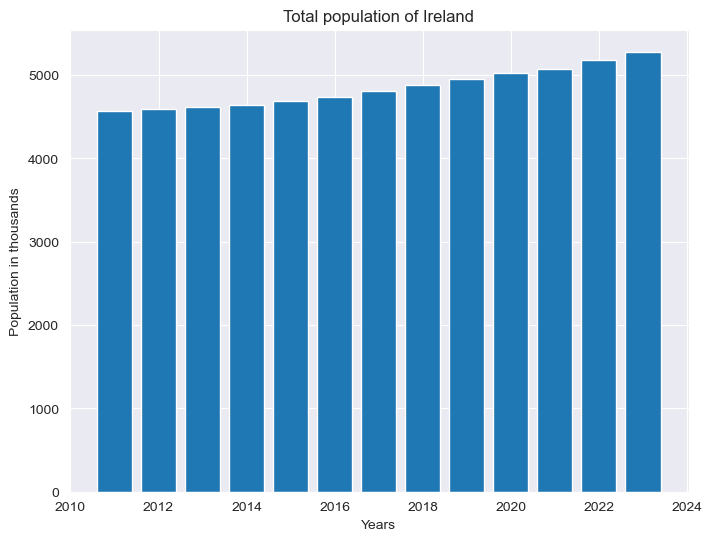

In [110]:
#Bar graph to compare population by year 2011-2023 
plt.figure(figsize=(8,6))
plt.bar(all_age_bt_sex_state_df['year'], all_age_bt_sex_state_df['value'])
plt.title("Total population of Ireland")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.show()

### Child population age 0-4 years, both sex, all states

In [111]:

age04_bt_sex_state_df = population_dataframe.loc[(population_dataframe['sex'] == 'Both sexes') & (population_dataframe['region'] == 'State') & (population_dataframe['age_group'] == '0 - 4 years')].reset_index(drop=True)
age04_bt_sex_state_df

,year,age_group,sex,region,value
0,2011,0 - 4 years,Both sexes,State,356.0
1,2012,0 - 4 years,Both sexes,State,358.2
2,2013,0 - 4 years,Both sexes,State,353.0
3,2014,0 - 4 years,Both sexes,State,345.4
4,2015,0 - 4 years,Both sexes,State,337.9
5,2016,0 - 4 years,Both sexes,State,331.4
6,2017,0 - 4 years,Both sexes,State,325.0
7,2018,0 - 4 years,Both sexes,State,320.0
8,2019,0 - 4 years,Both sexes,State,315.0
9,2020,0 - 4 years,Both sexes,State,308.7


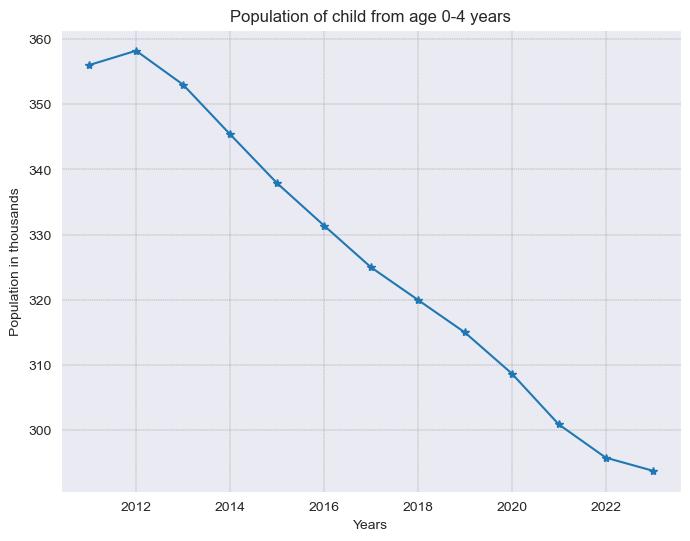

In [112]:
#Bar graph to compare population by year 2011-2023 
plt.figure(figsize=(8,6))
plt.plot(age04_bt_sex_state_df['year'], age04_bt_sex_state_df['value'], marker='*')
plt.title("Population of child from age 0-4 years")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.grid(color = 'grey', linestyle = '--', linewidth = 0.3)
plt.show()

# why child birth is decreasing each year -> research

###  Older Adults Population age 85 years and above , both sex, all states

In [113]:
age85_above_bt_sex_state_df = population_dataframe.loc[(population_dataframe['sex'] == 'Both sexes') & (population_dataframe['region'] == 'State') & (population_dataframe['age_group'] == '85 years and over')].reset_index(drop=True)
age85_above_bt_sex_state_df

,year,age_group,sex,region,value
0,2011,85 years and over,Both sexes,State,58.2
1,2012,85 years and over,Both sexes,State,59.8
2,2013,85 years and over,Both sexes,State,60.7
3,2014,85 years and over,Both sexes,State,62.7
4,2015,85 years and over,Both sexes,State,64.9
5,2016,85 years and over,Both sexes,State,67.3
6,2017,85 years and over,Both sexes,State,69.1
7,2018,85 years and over,Both sexes,State,71.8
8,2019,85 years and over,Both sexes,State,74.1
9,2020,85 years and over,Both sexes,State,75.6


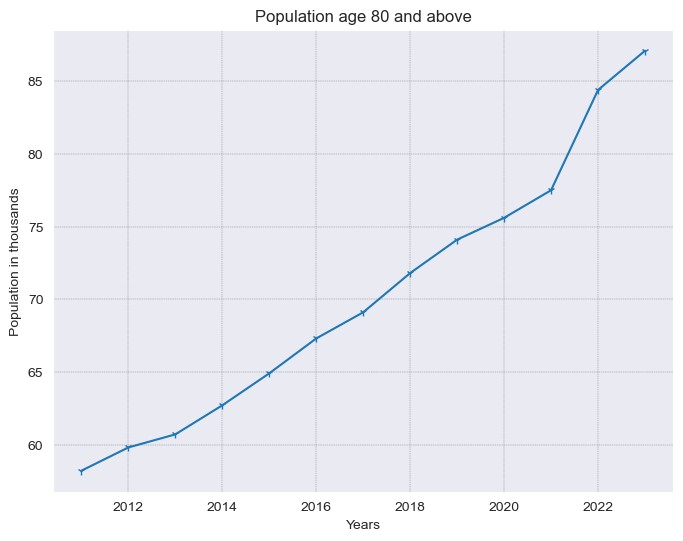

In [114]:
#Bar graph to compare population by year 2011-2023 
plt.figure(figsize=(8,6))
plt.plot(age85_above_bt_sex_state_df['year'], age85_above_bt_sex_state_df['value'], marker='1')
plt.title("Population age 80 and above")
plt.ylabel("Population in thousands")
plt.xlabel("Years")
plt.grid(color = 'grey', linestyle = '--', linewidth = 0.3)
plt.show()

#### Define Class with method get_age_data() to get data frame based on  different age group

In [115]:
# Define class name PopulationByAgeGroup
class PopulationByAgeGroup:
    
    # __init__() is Constructor: The function that runs whenever we make a new object i.e population_data 
    def __init__(self, population_dataframe):
        self.population_dataframe = population_dataframe
        
        #gives uniques all age group
        self.age_group_only = population_dataframe['age_group'].unique()
        print('All age group: ',self.age_group_only)
        
    def get_age_data(self, start_age, end_age, sex, region):
        age_group_years = self.age_group_only[start_age: end_age]
        print('age_group_years',age_group_years)

        # find either value from different age exist or not 
        has_age_group = population_dataframe['age_group'].isin(age_group_years)
        
        # filter data age lies from '15 - 19 years' to  '60 - 64 years'
        filter_age_group_df = (population_dataframe.loc[has_age_group])
        print(filter_age_group_df)
        age_group_df = filter_age_group_df.loc[(filter_age_group_df['sex'] == sex) & (filter_age_group_df['region'] == region)]
        age_group_df = age_group_df.groupby(['year']).sum().reset_index()
        return age_group_df


# Initilization of Class PopulationByAgeGroup
population_data = PopulationByAgeGroup(population_dataframe)

All age group:  ['0 - 4 years' '5 - 9 years' '10 - 14 years' '15 - 19 years'
 '20 - 24 years' '25 - 29 years' '30 - 34 years' '35 - 39 years'
 '40 - 44 years' '45 - 49 years' '50 - 54 years' '55 - 59 years'
 '60 - 64 years' '65 - 69 years' '70 - 74 years' '75 - 79 years'
 '80 - 84 years' '85 years and over' 'All ages']


### Working population in ireland age 15-64

In [116]:
# get dataframe of age group from '15 - 19 years' to  '60 - 64 years'
# Call PopulationByAgeGroup
working_age_data = population_data.get_age_data(start_age = 3, end_age= 13, sex='Both sexes', region='State')
print('Woring population in Ireland by year : \n',working_age_data)


age_group_years ['15 - 19 years' '20 - 24 years' '25 - 29 years' '30 - 34 years'
 '35 - 39 years' '40 - 44 years' '45 - 49 years' '50 - 54 years'
 '55 - 59 years' '60 - 64 years']
      year      age_group         sex      region  value
81    2011  15 - 19 years  Both sexes       State  281.0
82    2011  15 - 19 years  Both sexes      Border   25.9
83    2011  15 - 19 years  Both sexes        West   27.9
84    2011  15 - 19 years  Both sexes    Mid-West   29.9
85    2011  15 - 19 years  Both sexes  South-East   25.9
86    2011  15 - 19 years  Both sexes  South-West   40.8
87    2011  15 - 19 years  Both sexes      Dublin   72.0
88    2011  15 - 19 years  Both sexes    Mid-East   40.7
89    2011  15 - 19 years  Both sexes     Midland   18.1
90    2011  15 - 19 years        Male       State  143.7
91    2011  15 - 19 years        Male      Border   13.3
92    2011  15 - 19 years        Male        West   14.2
93    2011  15 - 19 years        Male    Mid-West   15.3
94    2011  15 - 19 ye

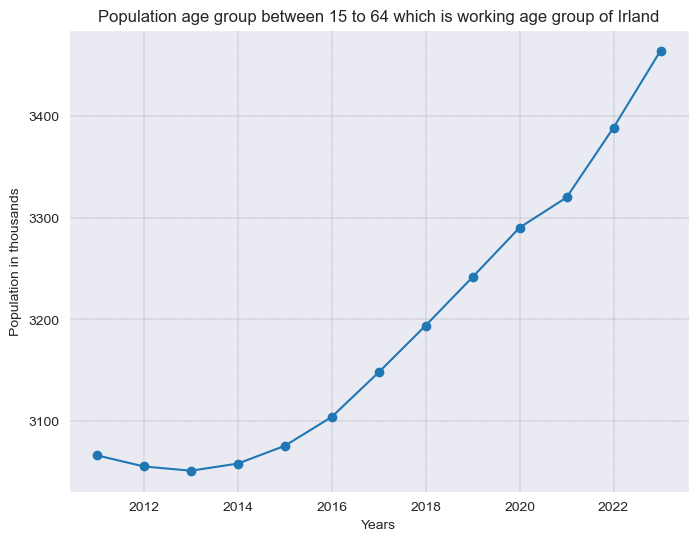

In [117]:
# function to plot line chart to show trend of population based on age group
def plot_linegraph(data_frame, title,  marker_icon):
    plt.figure(figsize=(8,6))
    plt.plot(data_frame['year'], data_frame['value'], marker=marker_icon)
    plt.title(title)
    plt.ylabel("Population in thousands")
    plt.xlabel("Years")
    plt.grid(color = 'grey', linestyle = '--', linewidth = 0.3)
    plt.show()
    
# line plot showing trend of working populatin in ireland by years
plot_linegraph(working_age_data, "Population age group between 15 to 64 which is working age group of Irland", "o")

### Children population in ireland age range  '0 - 4 years' to '15 - 19 years'

In [118]:
# get dataframe of age group from '0-4 years' to  '10 - 14 years'
# Call PopulationByAgeGroup
children_age_data = population_data.get_age_data(start_age = 0, end_age= 3, sex='Both sexes', region='State')
print('Children population in Ireland by year : \n',children_age_data)


age_group_years ['0 - 4 years' '5 - 9 years' '10 - 14 years']
      year      age_group         sex      region  value
0     2011    0 - 4 years  Both sexes       State  356.0
1     2011    0 - 4 years  Both sexes      Border   30.7
2     2011    0 - 4 years  Both sexes        West   32.6
3     2011    0 - 4 years  Both sexes    Mid-West   35.0
4     2011    0 - 4 years  Both sexes  South-East   32.0
5     2011    0 - 4 years  Both sexes  South-West   50.1
6     2011    0 - 4 years  Both sexes      Dublin   93.3
7     2011    0 - 4 years  Both sexes    Mid-East   58.5
8     2011    0 - 4 years  Both sexes     Midland   23.9
9     2011    0 - 4 years        Male       State  182.0
10    2011    0 - 4 years        Male      Border   15.8
11    2011    0 - 4 years        Male        West   16.6
12    2011    0 - 4 years        Male    Mid-West   18.0
13    2011    0 - 4 years        Male  South-East   16.4
14    2011    0 - 4 years        Male  South-West   25.5
15    2011    0 - 4 years 

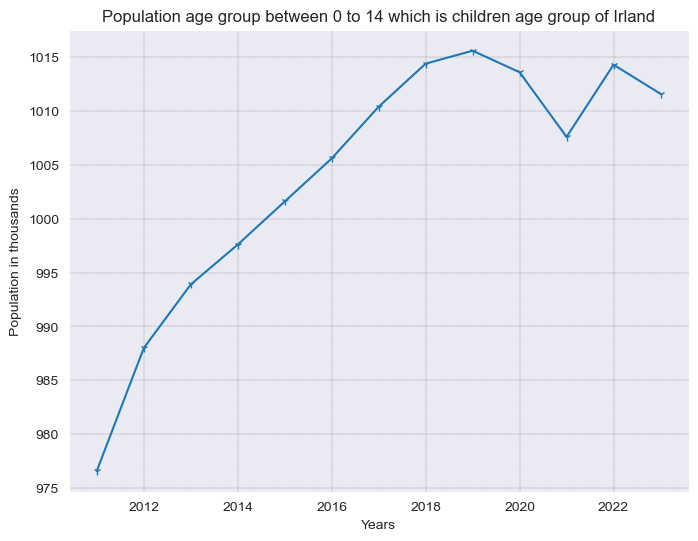

In [119]:
# line plot showing trend of working populatin in ireland by years
plot_linegraph(children_age_data, "Population age group between 0 to 14 which is children age group of Irland", "1")

### Older age population in ireland age range 65 and above

In [120]:
# Call PopulationByAgeGroup
older_age_data = population_data.get_age_data(start_age = 13, end_age= -1, sex='Both sexes', region='State')
print('Older population in Ireland by year : \n',working_age_data)

age_group_years ['65 - 69 years' '70 - 74 years' '75 - 79 years' '80 - 84 years'
 '85 years and over']
      year          age_group         sex      region  value
351   2011      65 - 69 years  Both sexes       State  172.1
352   2011      65 - 69 years  Both sexes      Border   16.1
353   2011      65 - 69 years  Both sexes        West   17.9
354   2011      65 - 69 years  Both sexes    Mid-West   19.2
355   2011      65 - 69 years  Both sexes  South-East   16.7
356   2011      65 - 69 years  Both sexes  South-West   26.4
357   2011      65 - 69 years  Both sexes      Dublin   43.3
358   2011      65 - 69 years  Both sexes    Mid-East   22.2
359   2011      65 - 69 years  Both sexes     Midland   10.3
360   2011      65 - 69 years        Male       State   85.6
361   2011      65 - 69 years        Male      Border    8.4
362   2011      65 - 69 years        Male        West    9.2
363   2011      65 - 69 years        Male    Mid-West    9.6
364   2011      65 - 69 years        Male  

### Chart data for Children, Working age and Older age for year 2023

In [121]:
chart_data_frame = [children_age_data, working_age_data, older_age_data]
chart_data_frame = pd.concat([children_age_data['year'], children_age_data['value'], working_age_data['value'], older_age_data['value']], keys=['year','children','working','older'], axis=1).reset_index(drop=True)
chart_data_frame

,year,children,working,older
0,2011,976.6,3066.6,531.6
1,2012,988.0,3055.7,549.9
2,2013,993.9,3051.5,569.2
3,2014,997.6,3058.5,589.5
4,2015,1001.6,3075.9,610.3
5,2016,1005.6,3104.3,629.9
6,2017,1010.4,3148.1,652.4
7,2018,1014.4,3194.0,676.5
8,2019,1015.6,3241.6,701.3
9,2020,1013.6,3290.1,726.1


In [122]:
chart_data_frame = chart_data_frame[chart_data_frame['year'] == 2023].reset_index(drop=True)
chart_data_frame

,year,children,working,older
0,2023,1011.6,3463.7,806.3


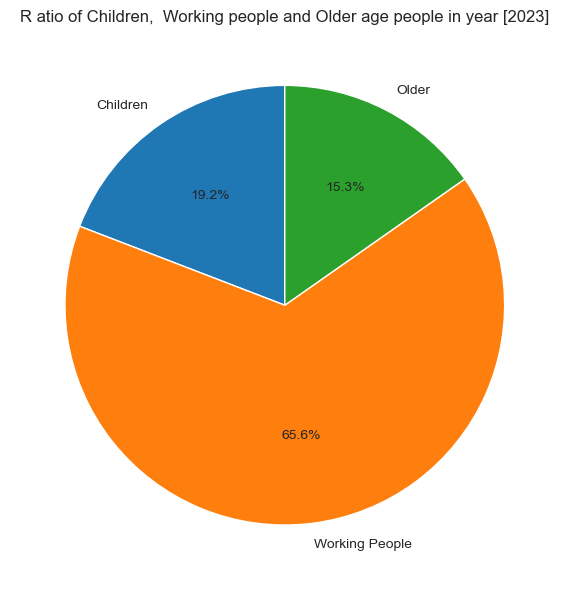

In [123]:
pie_data = chart_data_frame.iloc[:,1:].values.flatten()
years = chart_data_frame.iloc[:, 0].values
plt.figure(figsize=(8,6))
plt.pie(pie_data, labels=['Children', 'Working People', 'Older'], shadow=False, startangle=90, autopct='%1.1f%%', wedgeprops={'edgecolor': '#ffffff'} )
plt.title(f'R atio of Children,  Working people and Older age people in year {years}')
plt.tight_layout()
plt.show()

In [124]:
# Filter data for 'Male' and 'Female' sexes
filter_mf_df = newdata_no_outliers[(newdata_no_outliers['sex'] == 'Male') | (newdata_no_outliers['sex'] == 'Female')]
male_female_df = filter_mf_df.groupby(['year','region','sex'])['value'].sum()
male_female_df


year  region      sex   
2011  Border      Female    195.0
                  Male      197.1
      Dublin      Female    140.3
                  Male      150.8
      Mid-East    Female    330.1
                  Male      327.3
      Mid-West    Female    233.0
                  Male      233.5
      Midland     Female    141.5
                  Male      142.5
      South-East  Female    205.4
                  Male      204.4
      South-West  Female    332.8
                  Male      329.6
      West        Female    220.3
                  Male      220.5
2012  Border      Female    194.6
                  Male      197.6
      Dublin      Female    177.7
                  Male      119.3
      Mid-East    Female    334.5
                  Male      330.3
      Mid-West    Female    234.9
                  Male      235.8
      Midland     Female    143.8
                  Male      143.5
      South-East  Female    206.4
                  Male      205.1
      South-West  Femal